In [2]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from pathlib import Path

In [3]:
# Descobre onde o notebook está e sobe uma pasta para achar a raiz do projeto
BASE_DIR = Path().resolve().parent 
DATA_DIR = BASE_DIR / "data"

df = pd.read_csv(DATA_DIR / "tratados" / "acidentes_frota_17-25.csv")

In [4]:
df

,uf,br,dia_semana,fase_dia,sentido_via,condicao_metereologica,tipo_pista,uso_solo,tipo_veiculo,ano,...,Declive,Desvio Temporário,Em Obras,Interseção de Vias,Ponte,Reta,Retorno Regulamentado,Rotatória,Túnel,Viaduto
0,PR,376.0,domingo,Plena Noite,Crescente,Chuva,Simples,Não,Motocicleta,2017,...,0,0,0,0,0,1,0,0,0,0
1,SC,101.0,domingo,Plena Noite,Crescente,Chuva,Dupla,Não,Automóvel,2017,...,0,0,0,0,0,0,0,0,0,0
2,PR,153.0,domingo,Plena Noite,Decrescente,Garoa/Chuvisco,Simples,Não,Automóvel,2017,...,0,0,0,0,0,1,0,0,0,0
3,PR,153.0,domingo,Plena Noite,Decrescente,Garoa/Chuvisco,Simples,Não,Automóvel,2017,...,0,0,0,0,0,1,0,0,0,0
4,GO,153.0,domingo,Plena Noite,Decrescente,Céu Claro,Dupla,Sim,Motocicleta,2017,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4069966,PR,376.0,segunda-feira,Pleno dia,Crescente,Nublado,Simples,Não,Caminhão-trator,2025,...,0,0,0,0,0,0,0,0,0,0
4069967,SC,101.0,segunda-feira,Pleno dia,Crescente,Sol,Dupla,Sim,Automóvel,2025,...,0,0,0,0,0,1,0,0,0,0
4069968,SC,101.0,segunda-feira,Pleno dia,Crescente,Sol,Dupla,Sim,Caminhonete,2025,...,0,0,0,0,0,1,0,0,0,0
4069969,MG,381.0,domingo,Plena Noite,Decrescente,Nublado,Simples,Não,Automóvel,2025,...,0,0,0,1,0,1,0,0,0,0


In [4]:
df['tracado_via'].unique()

<ArrowStringArray>
[                                                 'Reta',
                                                 'Curva',
                                'Em Obras;Declive;Curva',
                                          'Aclive;Curva',
                                  'Aclive;Curva;Viaduto',
                                           'Reta;Aclive',
                                 'Retorno Regulamentado',
                                         'Curva;Declive',
                                           'Aclive;Reta',
                               'Reta;Interseção de Vias',
 ...
    'Em Obras;Reta;Desvio Temporário;Interseção de Vias',
            'Interseção de Vias;Declive;Rotatória;Curva',
              'Rotatória;Reta;Interseção de Vias;Aclive',
            'Rotatória;Interseção de Vias;Declive;Curva',
                                         'Ponte;Viaduto',
            'Desvio Temporário;Interseção de Vias;Curva',
           'Retorno Regulamentado;Rotatória;Acli

C:\Users\Elaine\AppData\Local\Temp\ipykernel_1868\1237141241.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='gravidade', palette='Set2')


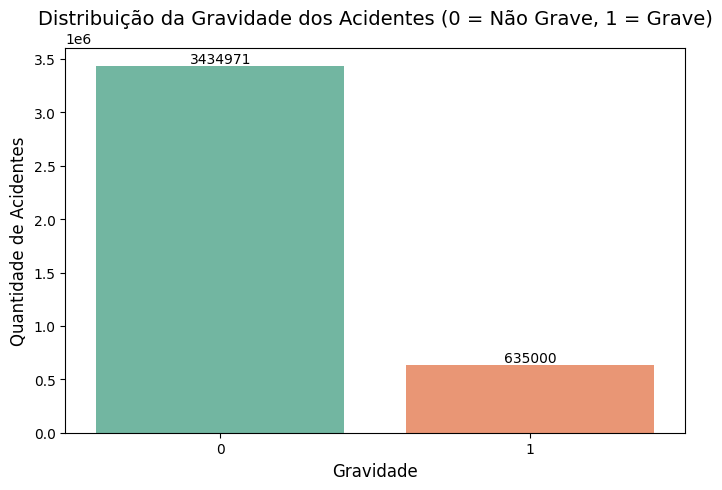

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='gravidade', palette='Set2')

plt.title('Distribuição da Gravidade dos Acidentes (0 = Não Grave, 1 = Grave)', fontsize=14)
plt.xlabel('Gravidade', fontsize=12)
plt.ylabel('Quantidade de Acidentes', fontsize=12)

# Adicionar os valores exatos em cima das barras para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

C:\Users\Elaine\AppData\Local\Temp\ipykernel_1868\979490586.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados_var, x='gravidade', y=var, ax=axes[i], palette='magma')
C:\Users\Elaine\AppData\Local\Temp\ipykernel_1868\979490586.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados_var, x='gravidade', y=var, ax=axes[i], palette='magma')
C:\Users\Elaine\AppData\Local\Temp\ipykernel_1868\979490586.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dados_var, x='gravidade', y=var, ax=axes[i], palette='magma')
C:\User

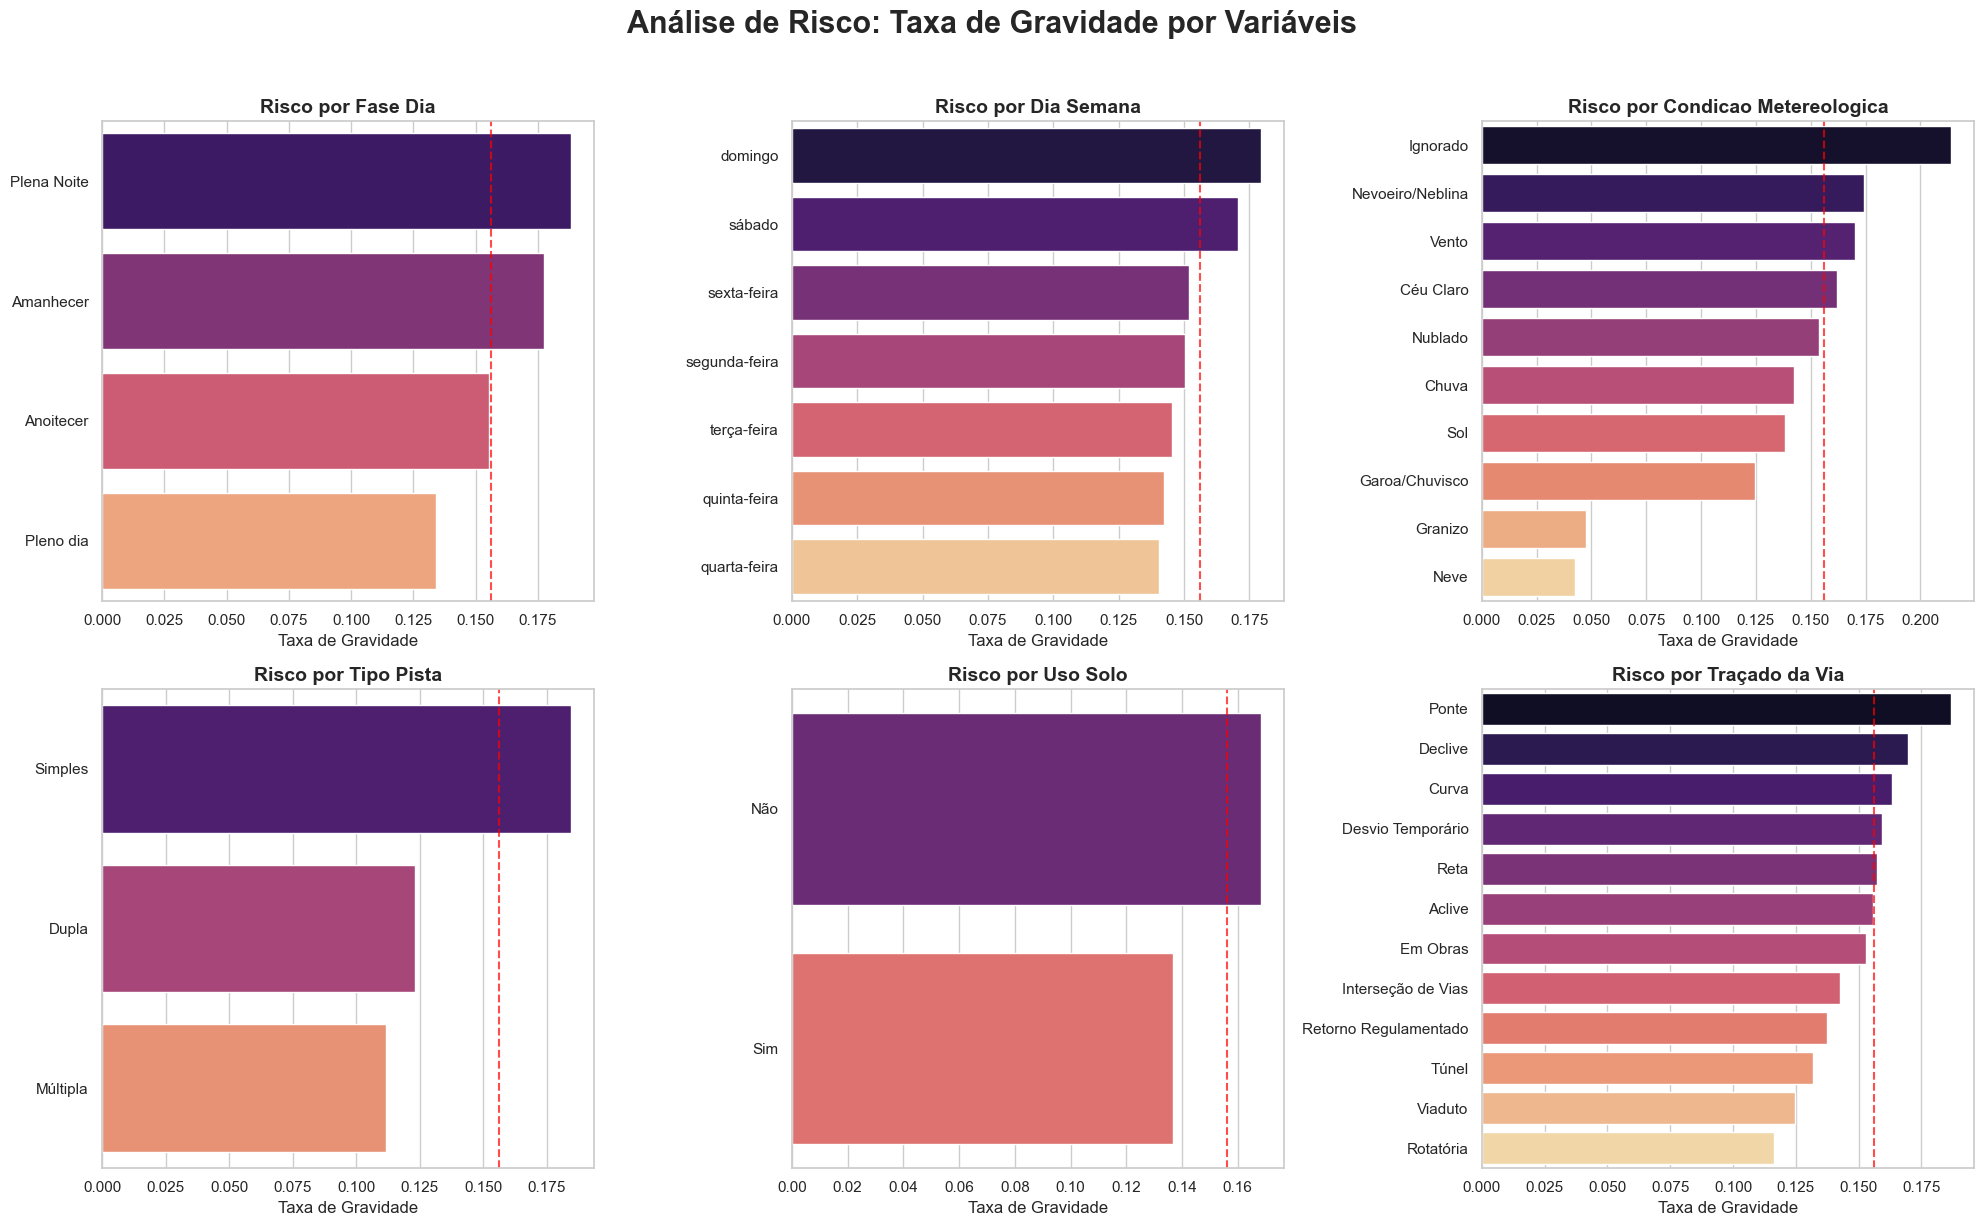

In [6]:
# 1. Separamos as variáveis normais das dummies
variaveis_normais = [
    'fase_dia', 
    'dia_semana', 
    'condicao_metereologica', 
    'tipo_pista', 
    'uso_solo'
]

# Lista exata das colunas dummies que você criou (ajuste se alguma letra maiúscula/acento estiver diferente no seu df)
dummies_tracado = [
    'Reta', 'Curva', 'Declive', 'Aclive', 'Interseção de Vias', 
    'Em Obras', 'Retorno Regulamentado', 'Rotatória', 'Ponte', 
    'Viaduto', 'Desvio Temporário', 'Túnel'
]

# 2. Configuração visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Análise de Risco: Taxa de Gravidade por Variáveis', fontsize=22, fontweight='bold', y=1.02)

axes = axes.flatten()
media_nacional = df['gravidade'].mean()

# 3. Loop para criar os 5 primeiros gráficos (Variáveis Normais)
for i, var in enumerate(variaveis_normais):
    dados_var = df.groupby(var)['gravidade'].mean().sort_values(ascending=False).reset_index()
    
    sns.barplot(data=dados_var, x='gravidade', y=var, ax=axes[i], palette='magma')
    
    titulo_limpo = var.replace('_', ' ').title() 
    axes[i].set_title(f'Risco por {titulo_limpo}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('') 
    axes[i].set_xlabel('Taxa de Gravidade') 
    axes[i].axvline(media_nacional, color='red', linestyle='--', alpha=0.7)

# 4. Criar o 6º gráfico (Índice 5) unindo as Dummies do Traçado da Via
taxas_tracado = []

# Calculamos a média de gravidade apenas onde a dummy é 1 (onde a característica existe)
for dummy in dummies_tracado:
    if dummy in df.columns: # Verifica se a coluna existe para evitar erros de digitação
        taxa = df[df[dummy] == 1]['gravidade'].mean()
        taxas_tracado.append({'Categoria': dummy, 'gravidade': taxa})

# Transforma a lista num DataFrame e ordena do maior risco para o menor
df_tracado = pd.DataFrame(taxas_tracado).sort_values(by='gravidade', ascending=False)

# Plota as dummies no último espaço do painel
sns.barplot(data=df_tracado, x='gravidade', y='Categoria', ax=axes[5], palette='magma')

axes[5].set_title('Risco por Traçado da Via', fontsize=14, fontweight='bold')
axes[5].set_ylabel('')
axes[5].set_xlabel('Taxa de Gravidade')
axes[5].axvline(media_nacional, color='red', linestyle='--', alpha=0.7)

# 5. Ajustar o layout
plt.tight_layout()
plt.show()

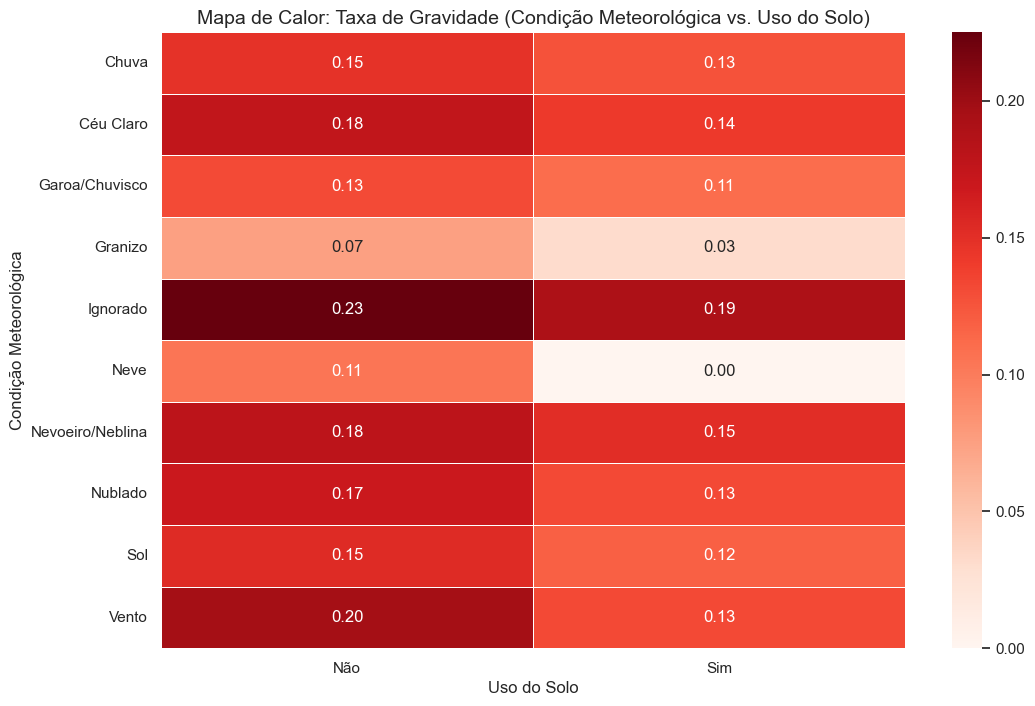

In [ ]:
# Criar uma tabela dinâmica calculando a taxa média de gravidade entre condição meteorólogica x solo
heatmap_data = df.pivot_table(
    values='gravidade', 
    index='condicao_metereologica', 
    columns='uso_solo', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', fmt='.2f', linewidths=.5)

plt.title('Mapa de Calor: Taxa de Gravidade (Condição Meteorológica vs. Uso do Solo)', fontsize=14)
plt.xlabel('Uso do Solo', fontsize=12)
plt.ylabel('Condição Meteorológica', fontsize=12)
plt.show()

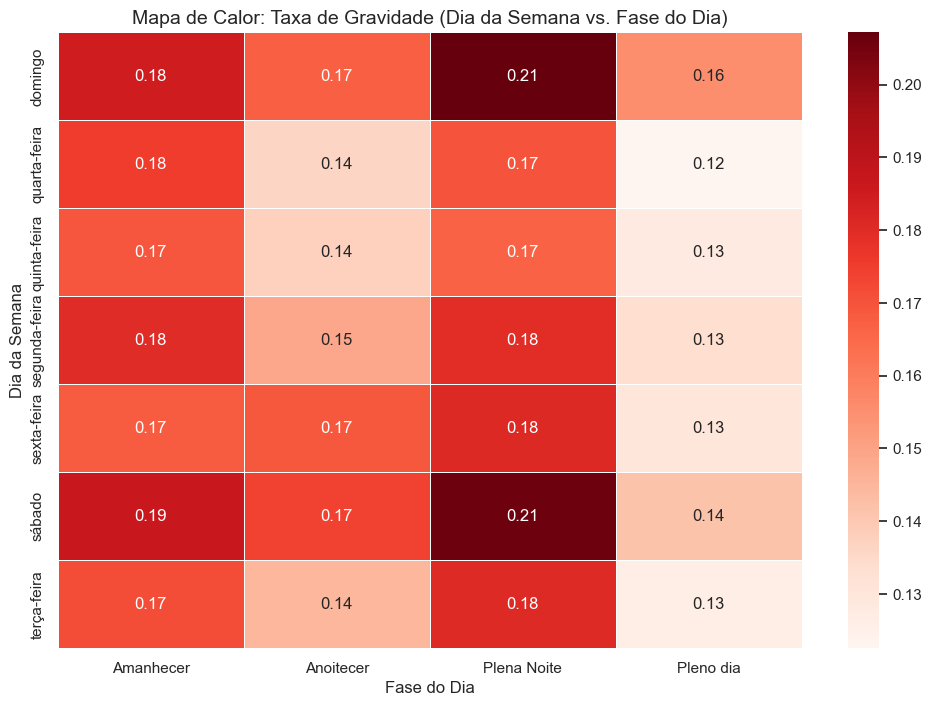

In [10]:
# Criar uma tabela dinâmica calculando a taxa média de gravidade entre dia da semana e fase do dia 
heatmap_data = df.pivot_table(
    values='gravidade', 
    index='dia_semana', 
    columns='fase_dia', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='Reds', fmt='.2f', linewidths=.5)

plt.title('Mapa de Calor: Taxa de Gravidade (Dia da Semana vs. Fase do Dia)', fontsize=14)
plt.xlabel('Fase do Dia', fontsize=12)
plt.ylabel('Dia da Semana', fontsize=12)
plt.show()

Tabela Dinâmica da Taxa Média de Gravidade (%):


tipo_pista,Dupla,Múltipla,Simples
Aclive,12.367180,11.990539,18.035743
Curva,12.187201,12.923522,18.790895
Declive,13.325708,11.999648,19.684017
Desvio Temporário,15.376197,14.904552,16.523908
Em Obras,14.852018,10.608402,16.147282
Interseção de Vias,12.298691,12.672276,15.434653
Ponte,11.913689,14.242054,21.167941
Reta,12.470179,10.940062,18.945263
Retorno Regulamentado,13.459135,14.843366,14.154206
Rotatória,10.914928,10.301651,12.112427


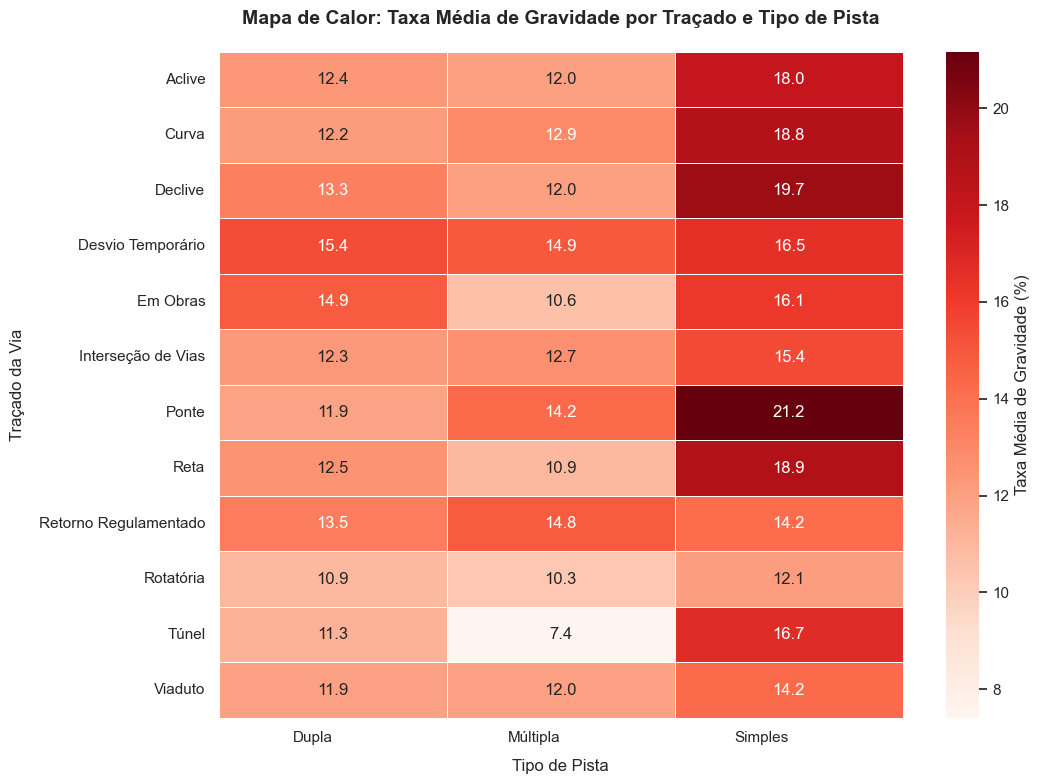

In [ ]:
# Criar uma tabela dinâmica calculando a taxa média de gravidade entre traçado e tipo de pista
col_gravidade = 'gravidade' 

colunas_tracado_base = [
    'Aclive', 'Curva', 'Declive', 'Desvio Temporário', 'Em Obras', 
    'Interseção de Vias', 'Ponte', 'Reta', 'Retorno Regulamentado', 
    'Rotatória', 'Túnel', 'Viaduto'
]

# Localiza as colunas de traçado no seu dataframe processado (mesmo com prefixo 'bin__')
cols_tracado = [c for c in df.columns if any(t in c for t in colunas_tracado_base)]

# Localiza a coluna original de texto 'tipo_pista'
col_tipo_pista = None
if 'tipo_pista' in df.columns:
    col_tipo_pista = 'tipo_pista'
else:
    for c in df.columns:
        if c.endswith('tipo_pista') and not any(dummy in c for dummy in ['Simples', 'Dupla', 'Multipla']):
            col_tipo_pista = c
            break

if col_tipo_pista is None:
    raise ValueError("A coluna original 'tipo_pista' não foi encontrada.")

# 2. CONSTRUIR A TABELA DINÂMICA (TAXA MÉDIA DE GRAVIDADE)

dicionario_linhas = {}

for col_tracado in cols_tracado:
    # 1. Filtra o dataframe trazendo apenas as linhas onde este traçado específico ocorreu (== 1)
    df_filtrado = df[df[col_tracado] == 1]
    
    # 2. Calcula a média da gravidade para cada tipo de pista neste cenário
    # NOTA: Se a sua coluna de gravidade for binária (0 para leve, 1 para grave), 
    # multiplicar por 100 transforma a média diretamente na porcentagem (%) de acidentes graves.
    media_gravidade = df_filtrado.groupby(col_tipo_pista)[col_gravidade].mean() * 100
    
    # 3. Remove o prefixo técnico (como 'bin__') para o nome da linha ficar limpo
    nome_linha_limpo = col_tracado.replace('bin__', '').replace('cat__', '')
    
    # 4. Salva o resultado desta linha
    dicionario_linhas[nome_linha_limpo] = media_gravidade

# Une todas as linhas criadas para formar a Tabela Dinâmica final
tabela_dinamica_gravidade = pd.DataFrame(dicionario_linhas).T


# 3. EXIBIR A TABELA NO JUPYTER (Opcional, para você ver os números puramente)

print("Tabela Dinâmica da Taxa Média de Gravidade (%):")
display(tabela_dinamica_gravidade)


# 4. PLOTAR O MAPA DE CALOR (HEATMAP)

plt.figure(figsize=(11, 8))

sns.heatmap(
    tabela_dinamica_gravidade, 
    annot=True,             # Mostra a taxa de gravidade dentro de cada bloco
    cmap='Reds',            # Tons de Vermelho (perfeito para indicar criticidade/perigo)
    fmt='.1f',              # Exibe com 1 casa decimal (ex: 14.3%)
    linewidths=0.5,         # Linha fina para separar visualmente as células
    cbar_kws={'label': 'Taxa Média de Gravidade (%)'}
)

plt.title('Mapa de Calor: Taxa Média de Gravidade por Traçado e Tipo de Pista', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Pista', fontsize=12, labelpad=10)
plt.ylabel('Traçado da Via', fontsize=12, labelpad=10)

plt.xticks(ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

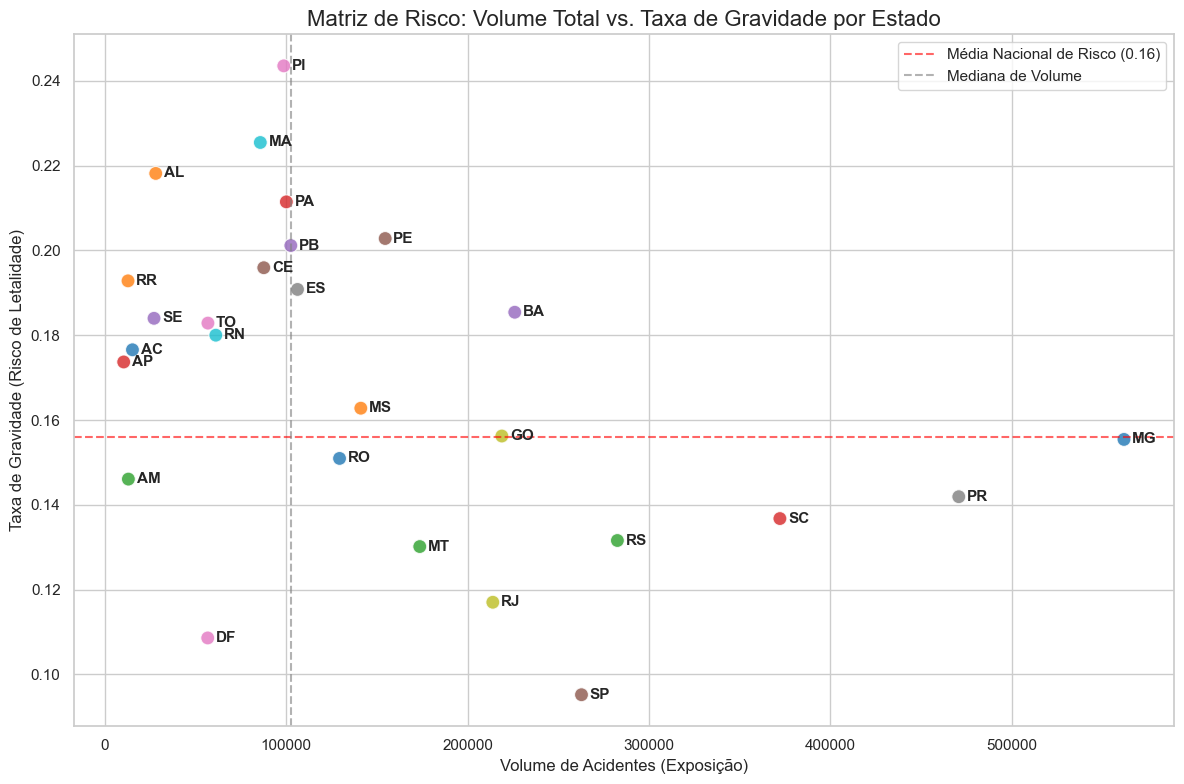

In [12]:
# 1. Agrupar os dados calculando o Volume e a Taxa de Gravidade ao mesmo tempo
dados_veiculo = df.groupby('uf').agg(
    volume=('gravidade', 'count'),
    taxa_gravidade=('gravidade', 'mean')
).reset_index()

# 2. Configuração do gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Criar o Scatter Plot (Gráfico de Dispersão)
# Usamos o volume também no parâmetro 'size' para fazer um gráfico de bolhas
sns.scatterplot(
    data=dados_veiculo, 
    x='volume', 
    y='taxa_gravidade', 
    hue='uf',
    s=100, # Tamanho mínimo e máximo das bolhas
    palette='tab10',
    alpha=0.8,
    legend=False # Desativamos a legenda para colocar os nomes direto nos pontos
)

# 4. Adicionar os nomes dos veículos ao lado de cada bolha
for i in range(dados_veiculo.shape[0]):
    plt.text(
        x=dados_veiculo['volume'][i] + (dados_veiculo['volume'].max() * 0.008), # Deslocamento no eixo X
        y=dados_veiculo['taxa_gravidade'][i], 
        s=dados_veiculo['uf'][i], 
        fontsize=11,
        fontweight='bold',
        verticalalignment='center'
    )

# 5. Adicionar Linhas de Referência (Criando os Quadrantes)
# Linha horizontal: Média nacional de risco
media_risco = df['gravidade'].mean()
plt.axhline(media_risco, color='red', linestyle='--', alpha=0.6, 
            label=f'Média Nacional de Risco ({media_risco:.2f})')

# Linha vertical: Mediana do volume (para separar quem bate muito de quem bate pouco)
mediana_volume = dados_veiculo['volume'].median()
plt.axvline(mediana_volume, color='gray', linestyle='--', alpha=0.6, 
            label='Mediana de Volume')

# 6. Títulos e Eixos
plt.title('Matriz de Risco: Volume Total vs. Taxa de Gravidade por Estado', fontsize=16)
plt.xlabel('Volume de Acidentes (Exposição)', fontsize=12)
plt.ylabel('Taxa de Gravidade (Risco de Letalidade)', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

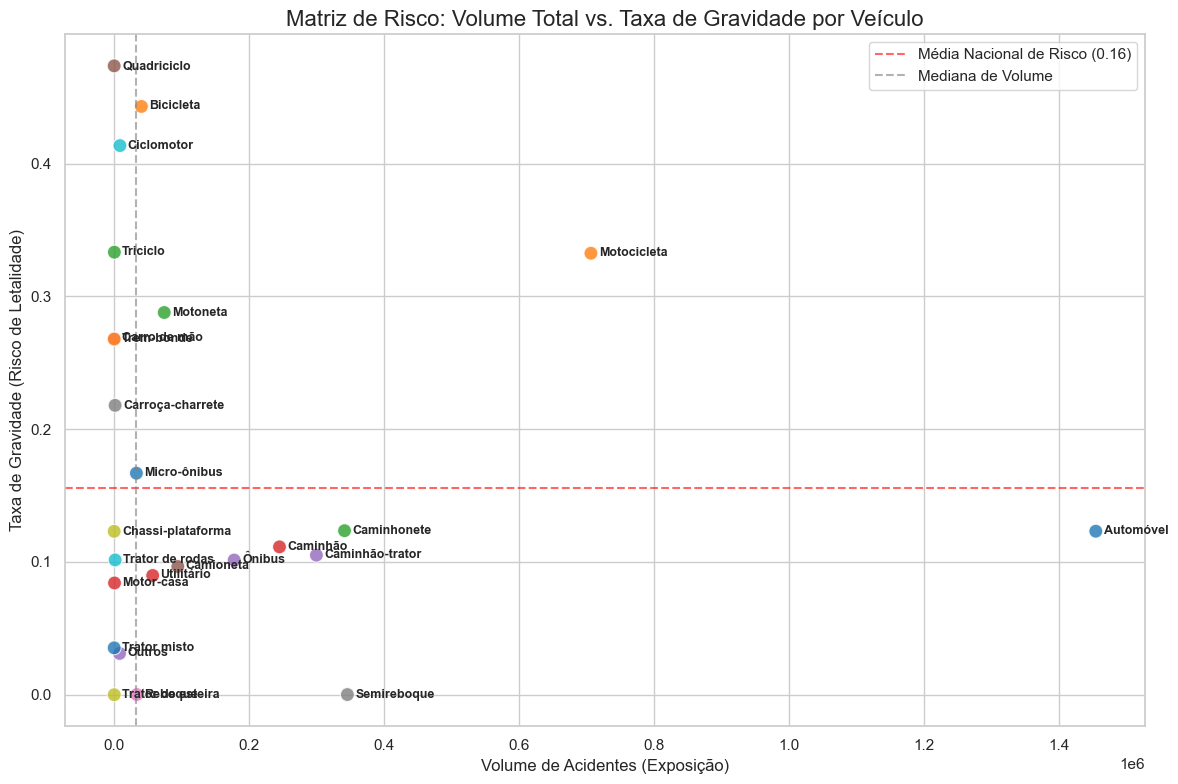

In [14]:
# 1. Agrupar os dados calculando o Volume e a Taxa de Gravidade ao mesmo tempo
dados_veiculo = df.groupby('tipo_veiculo').agg(
    volume=('gravidade', 'count'),
    taxa_gravidade=('gravidade', 'mean')
).reset_index()

# 2. Configuração do gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 3. Criar o Scatter Plot (Gráfico de Dispersão)
# Usamos o volume também no parâmetro 'size' para fazer um gráfico de bolhas
sns.scatterplot(
    data=dados_veiculo, 
    x='volume', 
    y='taxa_gravidade', 
    hue='tipo_veiculo',
    s=100, # Tamanho mínimo e máximo das bolhas
    palette='tab10',
    alpha=0.8,
    legend=False # Desativamos a legenda para colocar os nomes direto nos pontos
)

# 4. Adicionar os nomes dos veículos ao lado de cada bolha
for i in range(dados_veiculo.shape[0]):
    plt.text(
        x=dados_veiculo['volume'][i] + (dados_veiculo['volume'].max() * 0.008), # Deslocamento no eixo X
        y=dados_veiculo['taxa_gravidade'][i], 
        s=dados_veiculo['tipo_veiculo'][i], 
        fontsize=9,
        fontweight='bold',
        verticalalignment='center'
    )

# 5. Adicionar Linhas de Referência (Criando os Quadrantes)
# Linha horizontal: Média nacional de risco
media_risco = df['gravidade'].mean()
plt.axhline(media_risco, color='red', linestyle='--', alpha=0.6, 
            label=f'Média Nacional de Risco ({media_risco:.2f})')

# Linha vertical: Mediana do volume (para separar quem bate muito de quem bate pouco)
mediana_volume = dados_veiculo['volume'].median()
plt.axvline(mediana_volume, color='gray', linestyle='--', alpha=0.6, 
            label='Mediana de Volume')

# 6. Títulos e Eixos
plt.title('Matriz de Risco: Volume Total vs. Taxa de Gravidade por Veículo', fontsize=16)
plt.xlabel('Volume de Acidentes (Exposição)', fontsize=12)
plt.ylabel('Taxa de Gravidade (Risco de Letalidade)', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [15]:
# 1. Tamanho do dataset (linhas e colunas)
print(f"O dataset contém {df.shape[0]} registros de acidentes e {df.shape[1]} variáveis.")

# 2. Verificar dados nulos (isso é crucial justificar no TCC como você tratou)
print("\nQuantidade de dados nulos por variável:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Mostra apenas colunas com nulos

O dataset contém 4069971 registros de acidentes e 25 variáveis.

Quantidade de dados nulos por variável:
br               10090
tipo_veiculo    144908
frota            38358
br_km            10090
dtype: int64


In [16]:
# O método describe() calcula as estatísticas principais
# Vamos focar apenas em frota e km (ano e br são numéricos, mas agem como categorias)
desc_numericas = df[['frota']].describe().round(2)
display(desc_numericas)

,frota
count,4031613.00
mean,215808.90
std,706698.01
min,125.00
25%,10999.00
50%,43663.00
75%,170279.00
max,9965676.00
